# Импорт библиотек

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [4]:
data_name = 'creditcard'
df = pd.read_csv('creditcard.csv')

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)  

def data_analys(name, data):
    
    print(f'Анализ датасета –– {name}')
    print(f'\nКоличество строк: {data.shape[0]}\nКоличество столбцов: {data.shape[1]}')

    print(f'\nКоличество дубликатов: {data.duplicated().sum()}')
    print('% Дубликатов:', round(data.duplicated().sum() / len(data) * 100, 2))
    
    print('\nПервые 5 строк')
    display(data.head(5))

    print('\nОбзор данных датасета')
    overview = pd.DataFrame({
        'Тип': data.dtypes,
        'Уникальных': data.nunique(),
        '% Уникальных': (data.nunique() / len(data) * 100).round(2),
        'Пустых': data.isna().sum(),
        '% Пустых': (data.isna().sum() / len(data) * 100).round(2)
    })
    display(overview)

    print(f'\nОписательные статистики числовых столбцов')
    display(data.describe().round(2))

    print('\nИнтерквартильный размах и выбросы')
    num_cols = data.select_dtypes(include='number').columns.to_list()
    iqr_rows = []
    for col in num_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        low = Q1 - 1.5 * IQR
        high = Q3 + 1.5 * IQR
        outliers_mask = (data[col] < low) | (data[col] > high)
        outliers_count = outliers_mask.sum()
        iqr_rows.append({
            'Признак': col,
            'Нижняя граница': round(low, 2),
            'Верхняя граница': round(high, 2),
            'Выбросов (шт.)': outliers_count,
            'Выбросов (%)': round(outliers_count / len(data) * 100, 2)
        })
    iqr_stats = pd.DataFrame(iqr_rows)
    iqr_stats.set_index('Признак', inplace=True)
    display(iqr_stats)

In [6]:
data_analys(data_name, df)

Анализ датасета –– creditcard

Количество строк: 284807
Количество столбцов: 31

Количество дубликатов: 1081
% Дубликатов: 0.38

Первые 5 строк


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Обзор данных датасета


,Тип,Уникальных,% Уникальных,Пустых,% Пустых
Time,float64,124592,43.75,0,0.0
V1,float64,275663,96.79,0,0.0
V2,float64,275663,96.79,0,0.0
V3,float64,275663,96.79,0,0.0
V4,float64,275663,96.79,0,0.0
V5,float64,275663,96.79,0,0.0
V6,float64,275663,96.79,0,0.0
V7,float64,275663,96.79,0,0.0
V8,float64,275663,96.79,0,0.0
V9,float64,275663,96.79,0,0.0



Описательные статистики числовых столбцов


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,1.09,1.02,1.00,1.00,0.96,0.92,0.88,0.85,0.84,0.81,0.77,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,-24.59,-4.80,-18.68,-5.79,-19.21,-4.50,-14.13,-25.16,-9.50,-7.21,-54.50,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,-0.54,-0.76,-0.41,-0.65,-0.43,-0.58,-0.47,-0.48,-0.50,-0.46,-0.21,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,-0.09,-0.03,0.14,-0.01,0.05,0.05,0.07,-0.07,-0.00,0.00,-0.06,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,0.45,0.74,0.62,0.66,0.49,0.65,0.52,0.40,0.50,0.46,0.13,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,23.75,12.02,7.85,7.13,10.53,8.88,17.32,9.25,5.04,5.59,39.42,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00



Интерквартильный размах и выбросы


,Нижняя граница,Верхняя граница,Выбросов (шт.),Выбросов (%)
Признак,,,,
Time,-73477.00,266999.00,0,0.00
V1,-4.27,4.67,7062,2.48
V2,-2.70,2.91,13526,4.75
V3,-3.77,3.90,3363,1.18
V4,-3.24,3.13,11148,3.91
V5,-2.65,2.57,12295,4.32
V6,-2.52,2.15,22965,8.06
V7,-2.24,2.26,8948,3.14
V8,-1.01,1.13,24134,8.47


In [7]:
print('Распределение')
print(f'\n{(df.Class.value_counts(normalize=True) * 100).round(2)}')

Распределение

Class
0    99.83
1     0.17
Name: proportion, dtype: float64


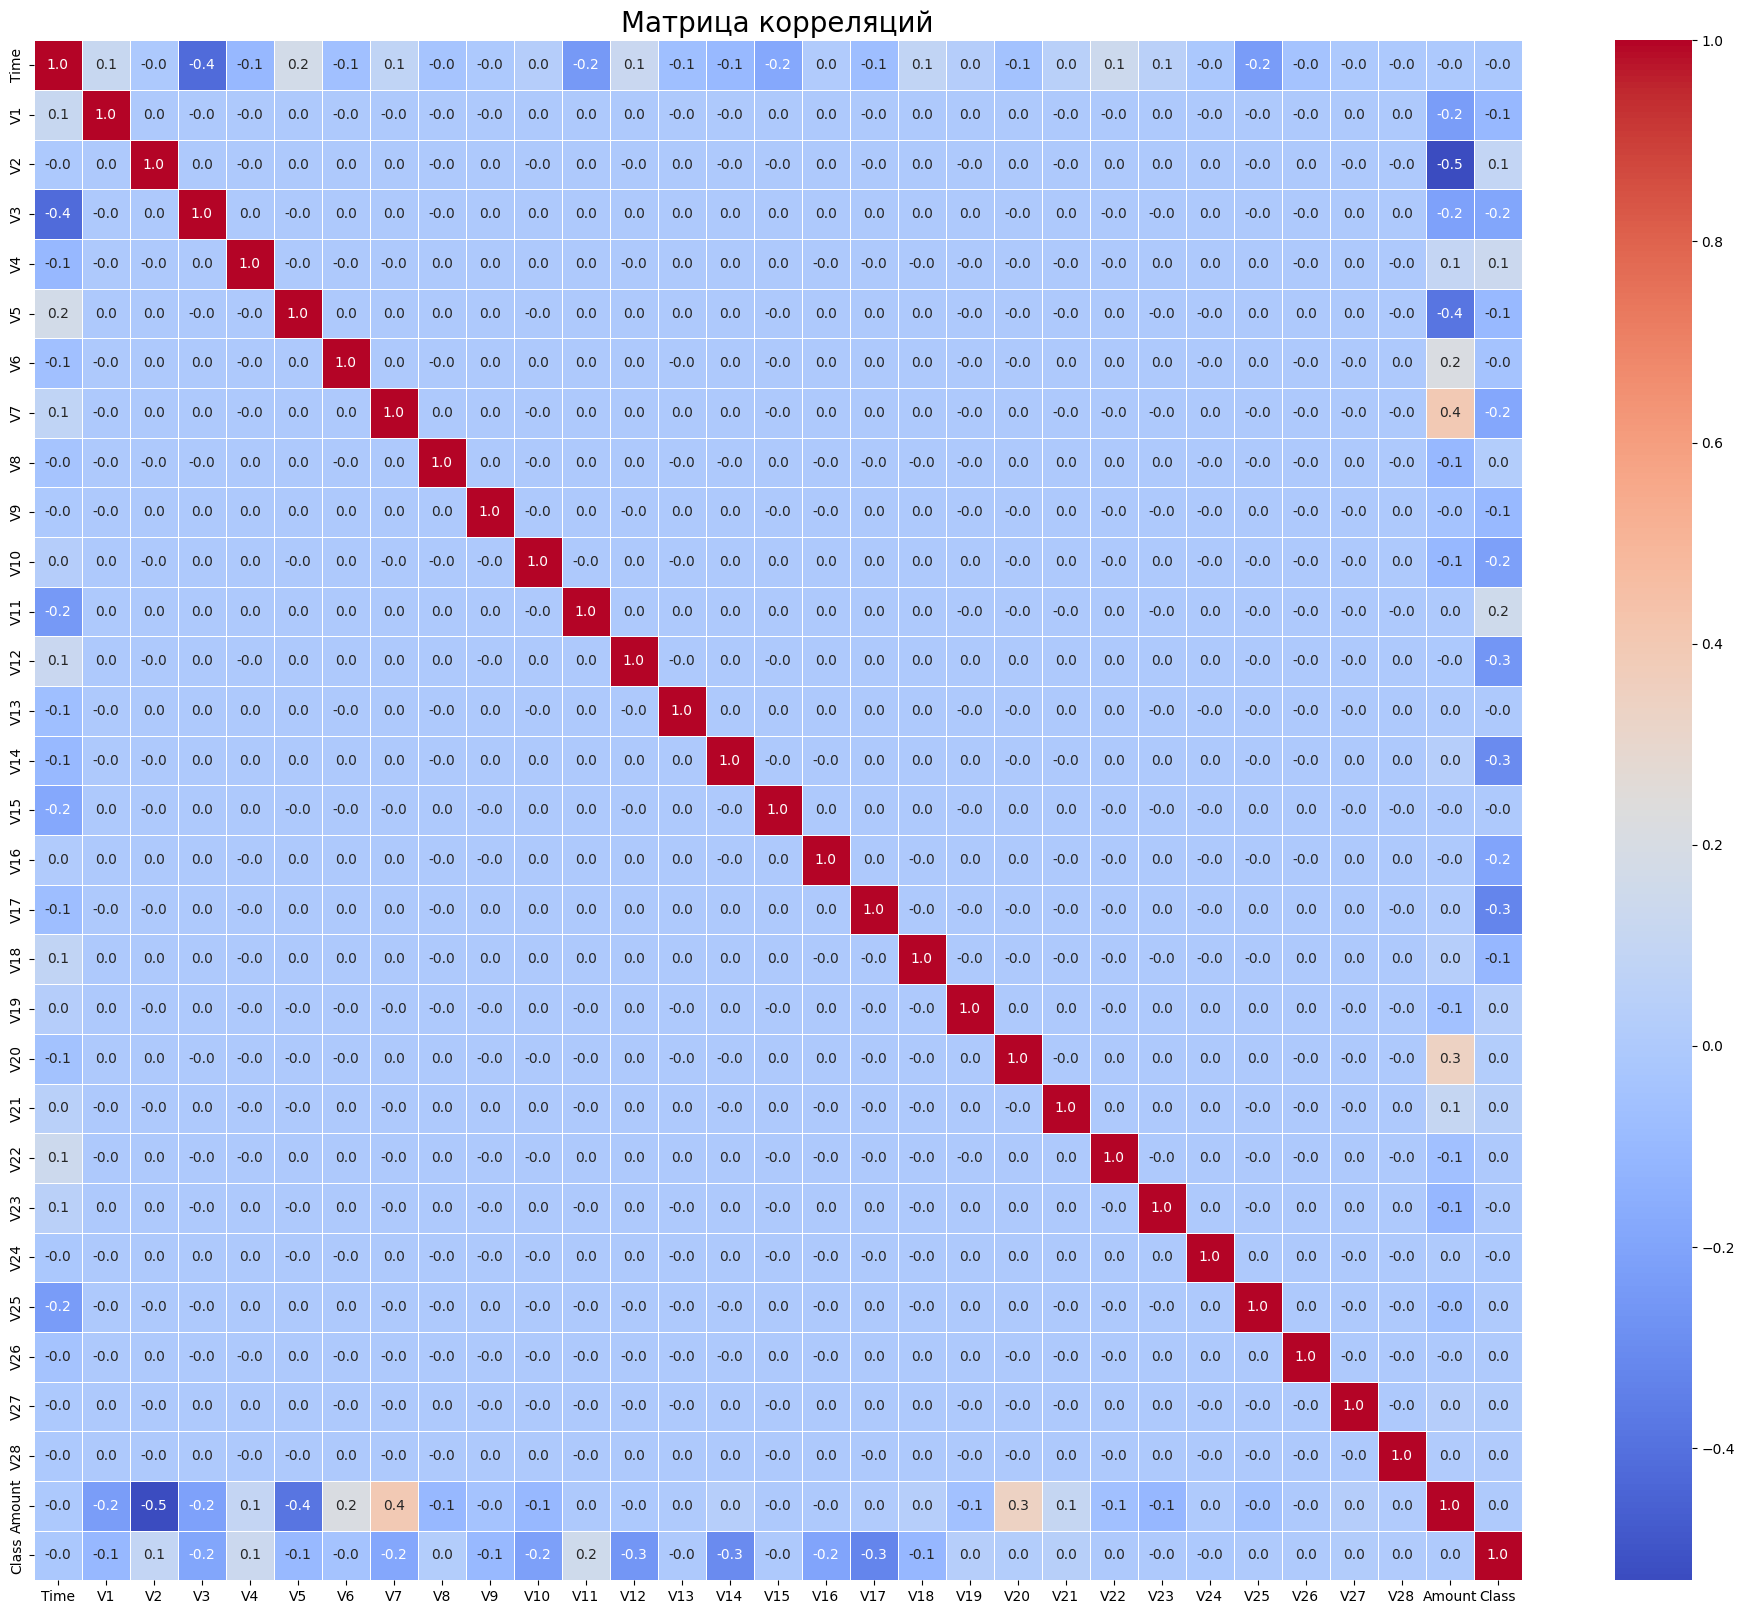

In [8]:
corr_matrix = df.corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".1f",    
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=True)

plt.title('Матрица корреляций', fontsize=20)
plt.show()

# Data Preparation

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Hour'] = (df['Time'] // 3600) % 24

df.drop('Time', axis=1, inplace=True)

In [11]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0
